## objectives

This notebook implements a ResNet50-based deep learning model for classifying waste image into six categories

The model will use transfer learning with a ResNet50 backbone
pretrained on ImageNet.

In [9]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf

print("TF version: ", tf.__version__)

TF version:  2.18.0


## 1. Experiment Configuration

In [10]:
IMG_SIZE = (256,256)
BATCH_SIZE = 16
NUM_CLASSES = 6
SEED = 42

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("Class Names: ", CLASS_NAMES)
print("Number of Classes: ", NUM_CLASSES)
print("Image Size: ", IMG_SIZE)
print("Batch Size: ", BATCH_SIZE)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Class Names:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of Classes:  6
Image Size:  (256, 256)
Batch Size:  16


In [12]:
TRAIN_CSV = "../data/processed/train.csv"
VAL_CSV = "../data/processed/validation.csv"
TEST_CSV = "../data/processed/test.csv"

print(os.path.exists(TRAIN_CSV))
print(os.path.exists(VAL_CSV))
print(os.path.exists(TEST_CSV))

True
True
True


In [14]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Training: (9692, 3)
Validation: (2114, 3)
Test: (2091, 3)


In [15]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['relative_path', 'class', 'label']

Validation columns:
['relative_path', 'class', 'label']

Test columns:
['relative_path', 'class', 'label']


In [19]:
train_df["class"].value_counts()

class
glass        1751
trash        1750
paper        1605
plastic      1598
cardboard    1548
metal        1440
Name: count, dtype: int64

In [24]:
sorted(train_df["class"].unique())
print("Number of classes:", train_df["label"].nunique())

Number of classes: 6


In [26]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64


In [28]:
print("Duplicate training rows:", train_df.duplicated().sum())
print("Duplicate validation rows:", val_df.duplicated().sum())
print("Duplicate test rows:", test_df.duplicated().sum())

Duplicate training rows: 0
Duplicate validation rows: 0
Duplicate test rows: 0


In [30]:
train_df.head()

,relative_path,class,label
0,cardboard/cardboard_00001.jpg,cardboard,0
1,cardboard/cardboard_00007.jpg,cardboard,0
2,cardboard/cardboard_00012.jpg,cardboard,0
3,cardboard/cardboard_00013.jpg,cardboard,0
4,cardboard/cardboard_00016.jpg,cardboard,0


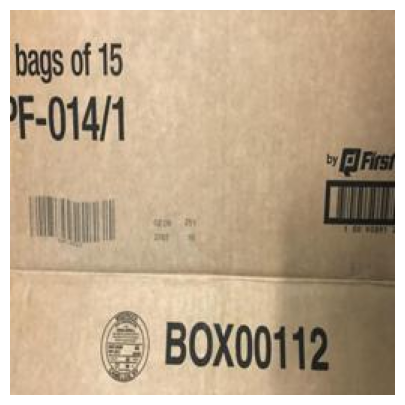

Image size: (256, 256)
Image mode: RGB


In [37]:
image = Image.open("../data/raw/Garbage_Dataset_Classification/images/cardboard/cardboard_00001.jpg")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Image size:", image.size)
print("Image mode:", image.mode)